In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import tensorflow as tf
from tensorflow.keras import layers
import sklearn
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, make_scorer, mean_squared_error, explained_variance_score
import matplotlib.dates as mdates
plt.rcParams['figure.figsize'] = (10, 5)
plt.style.use('fivethirtyeight')
import warnings
warnings.filterwarnings('ignore')

In [2]:
%reload_ext watermark
%watermark -a "Matheus dos Anjos" --iversions

Author: Matheus dos Anjos

seaborn   : 0.13.2
sklearn   : 1.5.1
plotly    : 5.24.1
tensorflow: 2.19.0
pandas    : 2.2.2
keras     : 3.10.0
numpy     : 1.26.4
matplotlib: 3.9.2



In [3]:
sns.set_style('darkgrid')

In [4]:
data = pd.read_csv('C:/Users/conta/OneDrive/Desktop/Series_Temporais_isp/BaseDPEvolucaoMensalCisp.csv', encoding='latin-1', sep=';')

In [5]:
data.head(10)

,cisp,mes,ano,mes_ano,aisp,risp,munic,mcirc,regiao,hom_doloso,...,cmp,cmba,ameaca,pessoas_desaparecidas,encontro_cadaver,encontro_ossada,pol_militares_mortos_serv,pol_civis_mortos_serv,registro_ocorrencias,fase
0,1,1,2003,2003m01,5,1,Rio de Janeiro,3304557,Capital,0,...,NaN,NaN,21,2,0,0,0,0,578,3
1,4,1,2003,2003m01,5,1,Rio de Janeiro,3304557,Capital,3,...,NaN,NaN,15,6,0,1,0,0,441,3
2,5,1,2003,2003m01,5,1,Rio de Janeiro,3304557,Capital,3,...,NaN,NaN,47,2,1,0,0,0,637,3
3,6,1,2003,2003m01,1,1,Rio de Janeiro,3304557,Capital,6,...,NaN,NaN,26,2,1,0,0,0,473,3
4,7,1,2003,2003m01,1,1,Rio de Janeiro,3304557,Capital,4,...,NaN,NaN,10,1,3,0,0,0,147,3
5,9,1,2003,2003m01,2,1,Rio de Janeiro,3304557,Capital,1,...,NaN,NaN,36,3,0,0,0,0,554,3
6,10,1,2003,2003m01,2,1,Rio de Janeiro,3304557,Capital,1,...,NaN,NaN,40,2,3,0,0,0,593,3
7,12,1,2003,2003m01,19,1,Rio de Janeiro,3304557,Capital,2,...,NaN,NaN,48,3,0,0,0,0,620,3
8,13,1,2003,2003m01,19,1,Rio de Janeiro,3304557,Capital,0,...,NaN,NaN,26,1,0,0,0,0,455,3
9,14,1,2003,2003m01,23,1,Rio de Janeiro,3304557,Capital,0,...,NaN,NaN,43,2,2,0,0,0,636,3


In [6]:
data.shape

(36081, 63)

In [7]:
df = data[['mes_ano', 'registro_ocorrencias']]

In [8]:
df.head()

,mes_ano,registro_ocorrencias
0,2003m01,578
1,2003m01,441
2,2003m01,637
3,2003m01,473
4,2003m01,147


In [9]:
df.shape

(36081, 2)

In [10]:
df['mes_ano'] = df['mes_ano'].str.replace('m', '/')
df['mes_ano'] = pd.to_datetime(df['mes_ano'], format='%Y/%m')

In [11]:
df = df.groupby('mes_ano', as_index=False)['registro_ocorrencias'].sum()

In [12]:
df.head()

,mes_ano,registro_ocorrencias
0,2003-01-01,44793
1,2003-02-01,45403
2,2003-03-01,45417
3,2003-04-01,44184
4,2003-05-01,45572


In [13]:
df.tail()

,mes_ano,registro_ocorrencias
263,2024-12-01,76987
264,2025-01-01,81562
265,2025-02-01,80306
266,2025-03-01,84129
267,2025-04-01,75761


In [14]:
df = df.set_index('mes_ano')

In [15]:
df.head()

,registro_ocorrencias
mes_ano,
2003-01-01,44793
2003-02-01,45403
2003-03-01,45417
2003-04-01,44184
2003-05-01,45572


In [16]:
df['registro_ocorrencias'].astype('float32')

mes_ano
2003-01-01    44793.0
2003-02-01    45403.0
2003-03-01    45417.0
2003-04-01    44184.0
2003-05-01    45572.0
               ...   
2024-12-01    76987.0
2025-01-01    81562.0
2025-02-01    80306.0
2025-03-01    84129.0
2025-04-01    75761.0
Name: registro_ocorrencias, Length: 268, dtype: float32

<Axes: xlabel='mes_ano'>

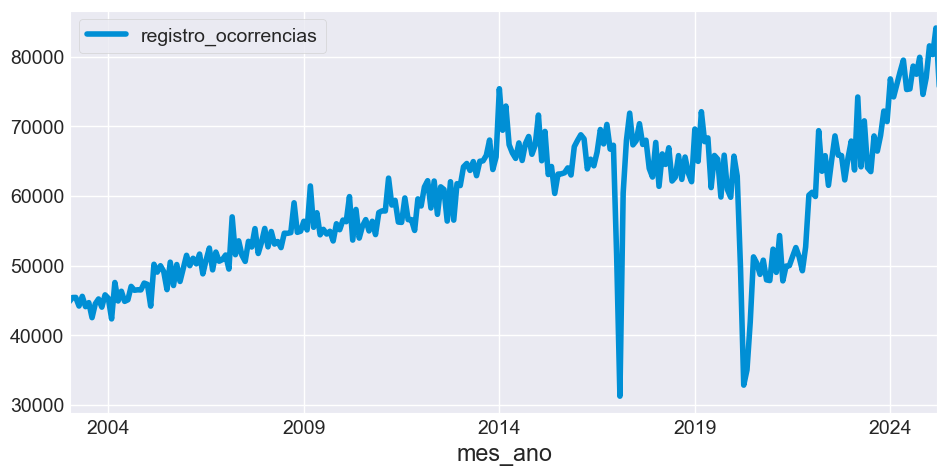

In [17]:
df.plot()

In [18]:
train_size = int(len(df) * 0.8)
test_size = len(df) - train_size

In [19]:
train, test = df.iloc[0:train_size], df.iloc[train_size:len(df)]

In [20]:
print('Tamanho de Treino:', len(train))
print('Tamanho de Teste:', len(test))

Tamanho de Treino: 214
Tamanho de Teste: 54


In [21]:
scaler_target = MinMaxScaler()

In [22]:
train['registro_ocorrencias'] = scaler_target.fit_transform(train['registro_ocorrencias'].to_numpy().reshape(-1, 1))

In [23]:
train.head()

,registro_ocorrencias
mes_ano,
2003-01-01,0.307027
2003-02-01,0.320837
2003-03-01,0.321154
2003-04-01,0.293240
2003-05-01,0.324663


In [24]:
train.tail()

,registro_ocorrencias
mes_ano,
2020-06-01,0.241805
2020-07-01,0.453025
2020-08-01,0.432785
2020-09-01,0.396201
2020-10-01,0.442384


In [25]:
test['registro_ocorrencias'] = scaler_target.transform(test[['registro_ocorrencias']])

In [26]:
test.head()

,registro_ocorrencias
mes_ano,
2020-11-01,0.378271
2020-12-01,0.376030
2021-01-01,0.478154
2021-02-01,0.402676
2021-03-01,0.522390


In [27]:
def createDataset(X, y, time_steps):
    
    Xs, ys = [], []
    
    for i in range(len(X) - time_steps):
        data = X.iloc[i:(i + time_steps)].values
        Xs.append(data)        
        ys.append(y.iloc[i + time_steps])
        
    return np.array(Xs), np.array(ys)

In [28]:
time_steps = 3

In [29]:
X_train, y_train = createDataset(train, train.registro_ocorrencias, time_steps)

In [30]:
X_test, y_test = createDataset(test, test.registro_ocorrencias, time_steps)

In [31]:
print(X_train.shape, y_train.shape)

(211, 3, 1) (211,)


In [32]:
print(X_test.shape, y_test.shape)

(51, 3, 1) (51,)


In [33]:
X_train_mlp = X_train[:, :, 0]

In [34]:
X_test_mlp = X_test[:, :, 0]

In [35]:
modelo_mlp = tf.keras.Sequential()
modelo_mlp.add(tf.keras.layers.Dense(16, input_dim=X_train_mlp.shape[1], activation='relu'))
modelo_mlp.add(tf.keras.layers.Dense(1))

In [36]:
modelo_mlp.compile(loss = 'mse', optimizer='adam')

In [37]:
modelo_mlp.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 81 (324.00 B)

 Trainable params: 81 (324.00 B)

 Non-trainable params: 0 (0.00 B)

In [38]:
%%time
modelo_mlp_history = modelo_mlp.fit(X_train_mlp,
                                    y_train,
                                    epochs = 200,
                                    batch_size = 16,
                                    validation_split = 0.2,
                                    shuffle=False,
                                    verbose=1)

'''shuffle=False: Mantém a ordem temporal dos dados, essencial para séries temporais.
epochs=200: Mais épocas permitem melhor ajuste, já que séries temporais podem precisar de mais iterações para convergir.
batch_size=8: Batches menores ajudam o modelo a aprender padrões em séries temporais pequenas.
validation_split=0.15: Um pouco mais de dados para validação ajuda a monitorar overfitting.
verbose=1: Mostra o progresso do treinamento.'''

Epoch 1/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.2765 - val_loss: 0.4871
Epoch 2/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1937 - val_loss: 0.3604
Epoch 3/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1334 - val_loss: 0.2597
Epoch 4/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0854 - val_loss: 0.1778
Epoch 5/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0486 - val_loss: 0.1149
Epoch 6/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0244 - val_loss: 0.0719
Epoch 7/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0118 - val_loss: 0.0469
Epoch 8/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0072 - val_loss: 0.0342
Epoch 9/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0068 - val_loss: 0.0284
Epoch 10/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0079 - val_loss: 0.0260
Epoch 11/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0089 - val_loss: 0.0251
Epoch 12/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.

'shuffle=False: Mantém a ordem temporal dos dados, essencial para séries temporais.\nepochs=200: Mais épocas permitem melhor ajuste, já que séries temporais podem precisar de mais iterações para convergir.\nbatch_size=8: Batches menores ajudam o modelo a aprender padrões em séries temporais pequenas.\nvalidation_split=0.15: Um pouco mais de dados para validação ajuda a monitorar overfitting.\nverbose=1: Mostra o progresso do treinamento.'

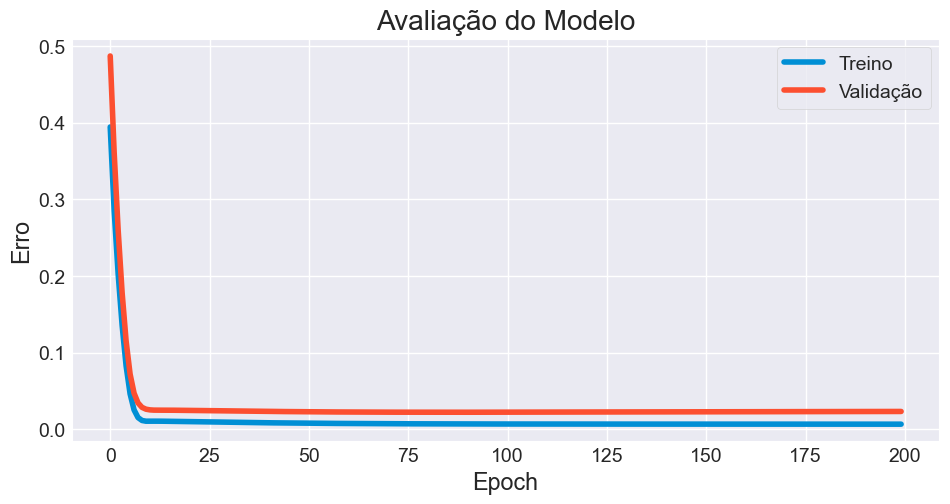

In [39]:
plt.plot(modelo_mlp_history.history['loss'])
plt.plot(modelo_mlp_history.history['val_loss'])
plt.title('Avaliação do Modelo')
plt.ylabel("Erro")
plt.xlabel('Epoch')
plt.legend(['Treino', 'Validação'], loc = 'upper right')
plt.show()

In [40]:
y_pred = modelo_mlp.predict(X_test_mlp)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


In [41]:
y_pred

array([[0.4364556 ],
       [0.43400925],
       [0.4869427 ],
       [0.43663597],
       [0.45444536],
       [0.4276231 ],
       [0.45221025],
       [0.47119677],
       [0.47561163],
       [0.45859152],
       [0.46781373],
       [0.5387671 ],
       [0.606819  ],
       [0.6496519 ],
       [0.72170687],
       [0.7093786 ],
       [0.7738298 ],
       [0.70774865],
       [0.7349986 ],
       [0.75915426],
       [0.7727132 ],
       [0.7830094 ],
       [0.7326778 ],
       [0.7417064 ],
       [0.75950515],
       [0.7478449 ],
       [0.82650447],
       [0.74318486],
       [0.84965765],
       [0.744053  ],
       [0.7657131 ],
       [0.7648081 ],
       [0.7667643 ],
       [0.81099117],
       [0.8377031 ],
       [0.85594934],
       [0.9181157 ],
       [0.91352785],
       [0.9682204 ],
       [0.97397715],
       [1.007325  ],
       [0.974417  ],
       [0.9804708 ],
       [0.9816701 ],
       [0.9834691 ],
       [1.0262017 ],
       [0.9633494 ],
       [0.996

In [42]:
y_train_inv = scaler_target.inverse_transform(y_train.reshape(1, -1)).flatten()
y_test_inv = scaler_target.inverse_transform(y_test.reshape(1, -1)).flatten()
y_pred_inv = scaler_target.inverse_transform(y_pred.reshape(1, -1)).flatten()

In [43]:
print(y_train_inv)
print(y_test_inv)
print(y_pred_inv)

[44184. 45572. 44092. 44673. 42511. 44508. 45199. 44024. 45787. 45289.
 42331. 47564. 44907. 46305. 44850. 45077. 47004. 46447. 46514. 46496.
 47478. 47294. 44168. 50182. 49051. 49975. 49133. 46539. 50486. 47128.
 50144. 47712. 49604. 51469. 49979. 51043. 50239. 51647. 48803. 50777.
 52511. 49377. 51934. 50619. 50853. 51514. 49494. 56991. 51559. 53550.
 51486. 50595. 53477. 52666. 55307. 51733. 53312. 55329. 52685. 54890.
 53085. 53450. 52578. 54643. 54629. 54732. 59018. 54772. 54934. 56360.
 55116. 61430. 55492. 57585. 54415. 55197. 54526. 54919. 53531. 56000.
 55145. 56534. 56299. 59907. 53658. 58057. 53942. 55674. 56596. 54971.
 56358. 54447. 57604. 57852. 57840. 62560. 58691. 59364. 56247. 56198.
 59713. 56593. 56597. 55043. 59577. 58558. 61283. 62187. 58264. 62143.
 57356. 61308. 60926. 56387. 62040. 56523. 61758. 61491. 64179. 64660.
 63662. 64934. 62910. 64980. 65047. 65831. 68030. 63796. 65609. 75403.
 69434. 72915. 67358. 66175. 65397. 67615. 65097. 67511. 68540. 65986.
 67296

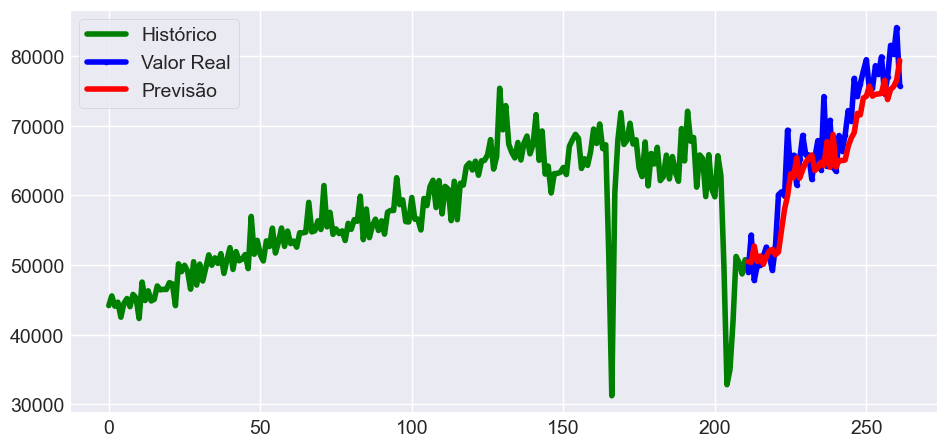

In [44]:
plt.plot(np.arange(0, len(y_train)), 
         y_train_inv, 
         color = 'green', 
         label = "Histórico")

plt.plot(np.arange(len(y_train), 
                   len(y_train) + len(y_test)), 
         y_test_inv, 
         color = 'blue', 
         marker = '.', 
         label = "Valor Real")

plt.plot(np.arange(len(y_train), 
                   len(y_train) + len(y_test)), 
         y_pred_inv, 
         color = 'red', 
         label = "Previsão")

plt.legend()
plt.show();

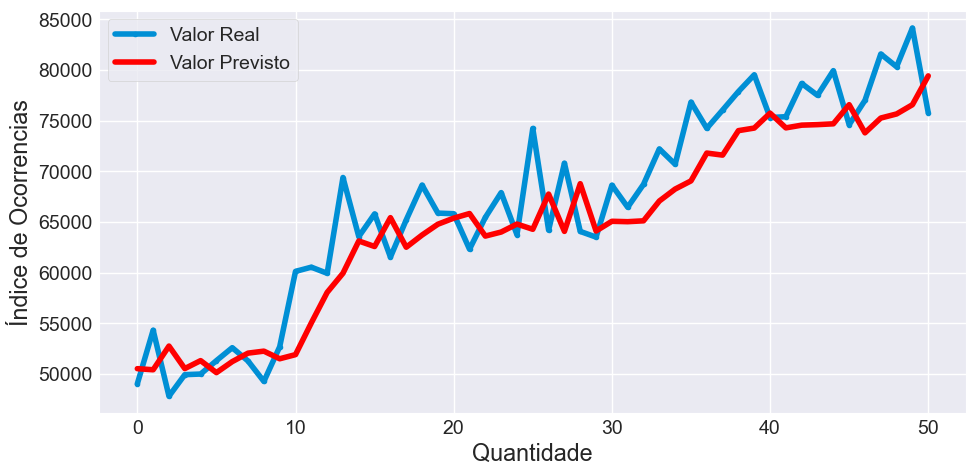

In [45]:
plt.plot(y_test_inv, marker = '.', label = "Valor Real")
plt.plot(y_pred_inv, color = 'red', label = "Valor Previsto")
plt.ylabel('Índice de Ocorrencias')
plt.xlabel('Quantidade')
plt.legend()
plt.show();

In [46]:
def mda(actual: np.ndarray, predicted: np.ndarray):
    return np.mean((np.sign(actual[1:] - actual[:-1]) == np.sign(predicted[1:] - predicted[:-1])).astype(int))

In [47]:
MDA_mlp = mda(y_test_inv, y_pred_inv)
print('MDA:', MDA_mlp)

MAE_mlp = mean_absolute_error(y_test_inv, y_pred_inv)
print('MAE:', MAE_mlp)

MSE_mlp = mean_squared_error(y_test_inv, y_pred_inv)
print('MSE:', MSE_mlp)

RMSE_mlp = mean_squared_error(y_test_inv, y_pred_inv, squared = False)
print('RMSE:', RMSE_mlp)

EVS_mlp = explained_variance_score(y_test_inv, y_pred_inv)
print('EVS Score:', EVS_mlp)

MDA: 0.38
MAE: 3499.988128063726
MSE: 17810065.114595607
RMSE: 4220.197283847712
EVS Score: 0.8636246221184882
